<a href="https://colab.research.google.com/github/liam77773smith/cb2330-portfolio/blob/main/Binomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FORWARD SIMULATION
theta = 0.7
Expected contacts: 29.4
Mean simulated contacts: 29.255
Standard deviation: 2.9185570064674087


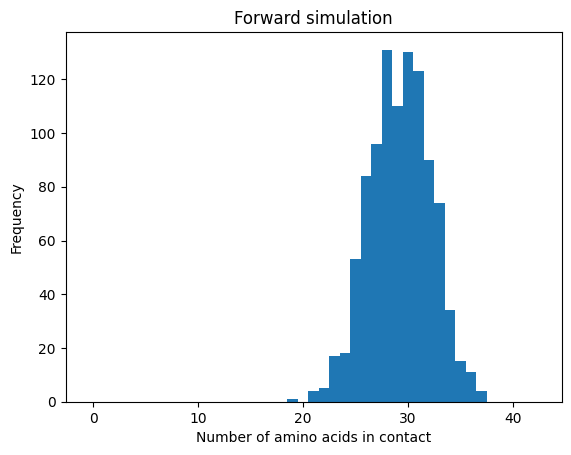


SIMULATED-TRUTH TEST
True theta: 0.7
Simulated observation: 28
Acceptance rate: 0.25605
Estimated theta: 0.6508869572396687 +/- 0.07770911621085241


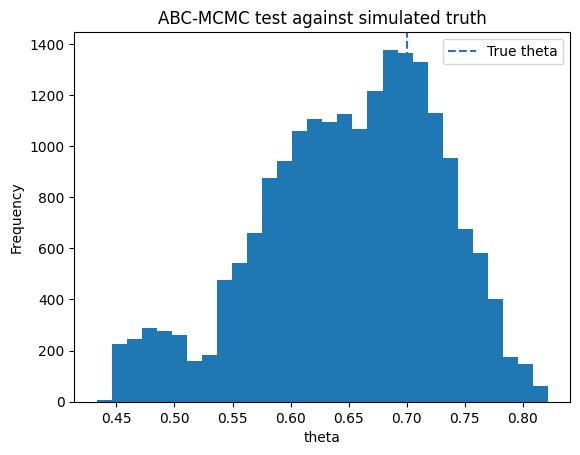


INFERENCE FROM PAPER
Observed contacts: 36
Acceptance rate: 0.33185
Estimated theta: 0.8304204998357091 +/- 0.06112057399822055
Observed fraction 36/42: 0.8571428571428571


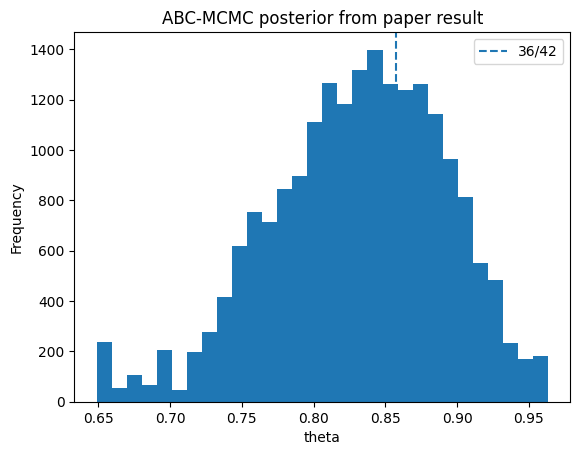


EPSILON = 0
Acceptance rate: 0.1293
Estimated theta: 0.8518146807510611 +/- 0.04398586524673686

EPSILON = 1
Acceptance rate: 0.33185
Estimated theta: 0.8304204998357091 +/- 0.06112057399822055

EPSILON = 2
Acceptance rate: 0.47455
Estimated theta: 0.8285327629203156 +/- 0.07661198402466819


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Paper observation
# ---------------------------------------------------------

N = 42

# The paper reports 36/42 amino acids in contact with
# the DOPS membrane at pH 7 at the free-energy minimum.
x_obs = 36


# ---------------------------------------------------------
# Random number generator
# ---------------------------------------------------------

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

seed = 30


def lcg(state, a, c, m):
    """The next state of a linear congruential generator:
    s_{i+1} = (a * s_i + c) mod m.
    """
    return (a * state + c) % m


# ---------------------------------------------------------
# Generative model
# ---------------------------------------------------------

# Random variable:
# X = number of amino acid residues in contact with the membrane.
#
# Parameter:
# theta = probability that one amino acid residue is in contact.
# theta is dimensionless and lies between 0 and 1.
#
# Model:
# X | theta ~ Binomial(42, theta)
#
# Expected value:
# E[X | theta] = 42 * theta


def simulation(theta, state, n_residues=N):
    """Simulate one observation: number of residues in contact."""

    contacts = 0

    for i in range(n_residues):

        state = lcg(state, A_LCG, C_LCG, M_LCG)
        r = state / M_LCG  # Random number between 0 and 1

        if r < theta:
            contacts += 1

    return contacts, state


# =========================================================
# 1. FORWARD SIMULATION
# =========================================================

# Choose a parameter independently of the paper result.
# The purpose is to see what data the model generates
# when theta is known.

theta = 0.70

n_simulations = 1000
simulated_contacts = [0] * n_simulations

state = seed

for i in range(n_simulations):
    simulated_contacts[i], state = simulation(theta, state)


print("FORWARD SIMULATION")
print("theta =", theta)
print("Expected contacts:", N * theta)
print("Mean simulated contacts:", np.mean(simulated_contacts))
print("Standard deviation:", np.std(simulated_contacts))


plt.hist(
    simulated_contacts,
    bins=range(0, N + 2),
    align="left"
)

plt.xlabel("Number of amino acids in contact")
plt.ylabel("Frequency")
plt.title("Forward simulation")
plt.show()


# =========================================================
# 2. ABC-MCMC
# =========================================================

# Flat prior between 0 and 1.
PRIOR = (0.0, 1.0)


def abc_mcmc(
    n_steps,
    epsilon,
    start,
    state,
    x_obs,
    half_width=0.03
):

    theta = start

    chain = [0.0] * n_steps

    n_acc = 0

    for t in range(n_steps):

        # Propose a new theta close to the current theta
        state = lcg(state, A_LCG, C_LCG, M_LCG)

        prop = theta + half_width * (
            2 * state / M_LCG - 1
        )

        # Only use proposed theta values inside the prior
        if PRIOR[0] <= prop <= PRIOR[1]:

            # Simulate one observation using proposed theta
            x_sim, state = simulation(prop, state)

            # ABC distance:
            # accept if simulated contacts are sufficiently
            # close to observed contacts
            if abs(x_sim - x_obs) <= epsilon:

                theta = prop
                n_acc += 1

        # Store the current theta after every MCMC step.
        # If the proposal was rejected, the previous theta
        # is stored again.
        chain[t] = theta

    return chain, n_acc, state


# =========================================================
# 3. TEST AGAINST SIMULATED TRUTH
# =========================================================

# Here we know the true parameter.
# We first generate fake observed data from the model.
# Then we pretend theta is unknown and see whether
# ABC-MCMC can recover the true parameter region.

True_Theta = 0.70

state = seed

x_test, state = simulation(
    True_Theta,
    state
)


print("\nSIMULATED-TRUTH TEST")
print("True theta:", True_Theta)
print("Simulated observation:", x_test)


chain_test, n_acc_test, state = abc_mcmc(
    n_steps=20000,
    epsilon=1,
    start=0.8,
    state=state,
    x_obs=x_test
)

posterior_test = chain_test


print(
    "Acceptance rate:",
    n_acc_test / len(chain_test)
)

print(
    "Estimated theta:",
    np.mean(posterior_test),
    "+/-",
    np.std(posterior_test)
)


plt.hist(
    posterior_test,
    bins=30
)

plt.axvline(
    True_Theta,
    linestyle="--",
    label="True theta"
)

plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC test against simulated truth")
plt.legend()
plt.show()


# =========================================================
# 4. ESTIMATE THETA FROM THE PAPER
# =========================================================

state = seed


chain, n_acc, state = abc_mcmc(
    n_steps=20000,
    epsilon=1,
    start=0.8,
    state=state,
    x_obs=x_obs
)

posterior = chain


print("\nINFERENCE FROM PAPER")
print("Observed contacts:", x_obs)

print(
    "Acceptance rate:",
    n_acc / len(chain)
)

print(
    "Estimated theta:",
    np.mean(posterior),
    "+/-",
    np.std(posterior)
)


# Direct estimate from the observed fraction.
# This is only a sanity check.
direct_estimate = x_obs / N

print(
    "Observed fraction 36/42:",
    direct_estimate
)


plt.hist(
    posterior,
    bins=30
)

plt.axvline(
    direct_estimate,
    linestyle="--",
    label="36/42"
)

plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC posterior from paper result")
plt.legend()
plt.show()


# =========================================================
# 5. EPSILON SENSITIVITY
# =========================================================

# Smaller epsilon means the simulated observation
# must be closer to the real observation.
#
# For x_obs = 36:
#
# epsilon = 0 -> only 36 is accepted
# epsilon = 1 -> 35, 36 or 37
# epsilon = 2 -> 34, 35, 36, 37 or 38


epsilons = [0, 1, 2]


for epsilon in epsilons:

    state = seed

    chain_eps, n_acc_eps, state = abc_mcmc(
        n_steps=20000,
        epsilon=epsilon,
        start=0.8,
        state=state,
        x_obs=x_obs
    )

    print("\nEPSILON =", epsilon)

    print(
        "Acceptance rate:",
        n_acc_eps / len(chain_eps)
    )

    print(
        "Estimated theta:",
        np.mean(chain_eps),
        "+/-",
        np.std(chain_eps)
    )


# =========================================================
# 6. ASSUMPTIONS AND LIMITATIONS
# =========================================================

# Assumptions:
#
# 1. Each amino acid residue is either in contact
#    or not in contact with the membrane.
#
# 2. Every amino acid residue has the same contact
#    probability theta.
#
# 3. Contacts between residues are treated as independent.
#
# 4. The observed 36 contacts are treated as one
#    observation from this stochastic process.
#
# 5. Residue identity, charge and position are not
#    explicitly included in the model.
#
#
# Limitations:
#
# The real peptide is a connected molecular structure,
# so residue contacts are unlikely to be truly independent.
#
# Different residues have different chemical properties
# and therefore probably do not have identical contact
# probabilities.
#
# The model does not explicitly describe peptide
# conformation, electrostatic interactions or membrane
# structure.
#
# ABC-MCMC is not computationally necessary for this
# simple Binomial model because the exact Binomial
# likelihood is known. It is used here to apply and test
# the simulation-based inference approach from the course.